In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.spatial.distance import pdist

import sys
sys.path.append("../..")

from gob.benchmarks import *
from gob.optimizers import *
import matplotlib
matplotlib.rcParams.update({"text.usetex": True})

In [2]:
class VisualWrapper:
  def __init__(self, func):
    self.func = func
    self.visual_bounds = func.visual_bounds
    self.samples = []
    self.values = []
    self.prev_sample = None
  
  def __call__(self, x):
    y = self.func(x)
    if self.prev_sample is None or not np.all(np.abs(x - self.prev_sample) <= 2e-9):
      self.samples.append(x)
      self.values.append(y)
    self.prev_sample = x
    return y

  def visualize(self):
    
    x_min, x_max = self.visual_bounds[0, :]
    y_min, y_max = self.visual_bounds[1, :]
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    zz = np.array([[self.func(np.array([x, y])) for x in np.linspace(x_min, x_max, 100)] for y in np.linspace(y_min, y_max, 100)])

    _ = plt.figure(1)
    ax = plt.axes(projection="3d", computed_zorder=False)
    ax.plot_surface(xx, yy, zz, linewidth=0.2, edgecolors="white", cmap="coolwarm", zorder=0)

    samples = np.array(self.samples)
    values = np.array(self.values)
    ax.scatter(samples[:, 0], samples[:, 1], values, c=values, cmap="viridis", zorder=1)
    ax.set_box_aspect(None, zoom=0.8)

  def visualize_distance(self, n_iter, n_particles):
    n_iter += 1
    if len(self.samples) <= n_iter * n_particles:
      # copy the last element until we have enough samples to visualize
      samples = self.samples + [self.samples[-1]] * (n_iter * n_particles - len(self.samples))
    elif len(self.samples) > n_iter * n_particles:
      samples = self.samples[:n_iter * n_particles]
    samples = np.array(samples)
    samples = samples.reshape(-1, n_particles, 2)

    # Calcul de la distance max à chaque itération
    def compute_metrics(samples):
        max_dist = np.array([
            pdist(samples[t]).max()
            for t in range(n_iter)
        ])
        variance = np.std(samples, axis = (1, 2))
        return max_dist, variance

    max_dist, var = compute_metrics(samples)
    mean_dist   = np.array([pdist(samples[t]).mean() for t in range(n_iter)])
    return max_dist, mean_dist, var

    """ # Plot
    #fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    fig, ax = plt.subplots()
    #ax.plot(max_dist, label='max')
    #ax[0].plot(var, label='var')
    ax.plot(mean_dist, label=r"$\frac{1}{N(N-1)} \sum_{i \neq j}^N \| X_i - X_j\|_2$")
    #ax.plot(var, label='var')
    ax.legend()
    #ax[1].legend() """
  
  def visualize_density(self, n_iter, n_particles, t, legend=False):
    n_iter += 1
    if len(self.samples) <= n_iter * n_particles:
      # copy the last element until we have enough samples to visualize
      samples = self.samples + [self.samples[-1]] * (n_iter * n_particles - len(self.samples))
    elif len(self.samples) > n_iter * n_particles:
      samples = self.samples[:n_iter * n_particles]
    samples = np.array(samples)
    samples = samples.reshape(-1, n_particles, 2)[t]
    fig, ax = plt.subplots()
    x_min, x_max = self.visual_bounds[0, :]
    y_min, y_max = self.visual_bounds[1, :]
    XX, YY = np.meshgrid(np.linspace(x_min-1, x_max+1, 100), np.linspace(y_min-1, y_max+1, 100))

    # Contours de la fonction objectif (arrière-plan)
    f_vec = np.vectorize(lambda xi, yi: self.func(np.array([xi, yi])))
    Z_obj = f_vec(XX, YY)
    ax.contour(XX, YY, Z_obj, levels=20, cmap='Greys', alpha=0.5)

    x, y = samples[:, 0], samples[:, 1]
    
    # Estimation de la densité par noyau (KDE)
    kde = gaussian_kde(samples.T, bw_method='scott')
    
    # Grille d'évaluation
    x_grid = np.linspace(x.min() - 1, x.max() + 1, 200)
    y_grid = np.linspace(y.min() - 1, y.max() + 1, 200)
    XX, YY = np.meshgrid(x_grid, y_grid)
    positions = np.vstack([XX.ravel(), YY.ravel()])

    
    # Évaluation de la densité sur la grille
    Z = kde(positions).reshape(XX.shape)
    
    # Plot
    ax.contourf(XX, YY, Z, levels=20, cmap='coolwarm')
    ax.scatter(x, y, c='red', s=10, alpha=0.5, label='particles')
    ax.set_xlim(x_min-1, x_max+1)
    ax.set_ylim(y_min-1, y_max+1)
    if legend:
      ax.legend()

<>:61: SyntaxWarning: invalid escape sequence '\s'
<>:61: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_206997/727492708.py:61: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(mean_dist, label=r"$\frac{1}{N(N-1)} \sum_{i \neq j}^N \| X_i - X_j\|_2$")


In [3]:
class Holder:
  visual_bounds = np.array([[-10, 10], [-10, 10]])
  
  def __call__(self, x):
    x1, x2 = x
    return -np.abs(np.sin(x1) * np.cos(x2) * np.exp(np.abs(1 - np.sqrt(x1**2 + x2**2) / np.pi)))

In [4]:
n_particles = 300
iter = 1000
snapshot = 800
f_ = lambda : VisualWrapper(Holder())
opt_ = CBO
smd_opt = SMD_CBO
gcn_opt = GCN_CBO
dt = 0.0001

Results for CBO: -19.196507874966954


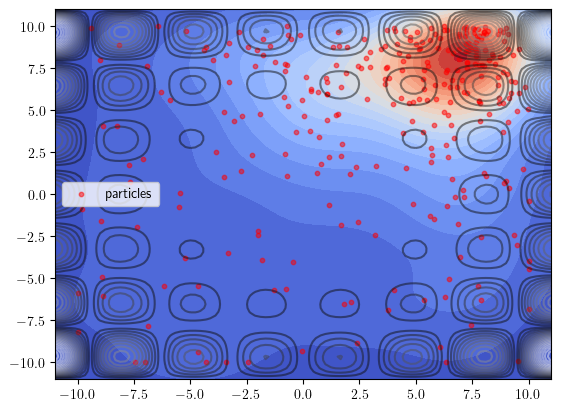

In [5]:
f = f_()

bounds = f.visual_bounds
sigma = 1 / n_particles**2
verbose = False

opt = opt_(bounds=bounds, n_particles=n_particles, iter=iter, verbose=verbose, dt=dt)
res = opt.minimize(f)
print(f"Results for {opt}: {res[1]}")
f.visualize_density(iter, n_particles, snapshot, True)
plt.savefig("exploration_cbo.svg", bbox_inches="tight")

In [6]:
cbo_max, cbo_mean, cbo_var = f.visualize_distance(iter, n_particles)

Results for SMD-CBO: -19.208435202662532


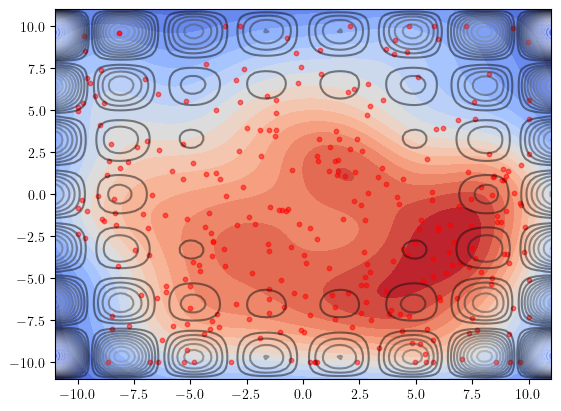

In [15]:
f = f_()

bounds = f.visual_bounds
sigma = 1 / n_particles**2
verbose = False

opt = smd_opt(bounds=bounds, n_particles=n_particles, iter=iter, verbose=verbose, dt=dt,
              moment="MVAR", gamma=1)
res = opt.minimize(f)
print(f"Results for {opt}: {res[1]}")
f.visualize_density(iter, n_particles, snapshot)
plt.savefig("exploration_smd_cbo.svg", bbox_inches="tight")

In [16]:
smd_cbo_max, smd_cbo_mean, smd_cbo_var = f.visualize_distance(iter, n_particles)

Results for GCN-CBO: -19.208499100419647


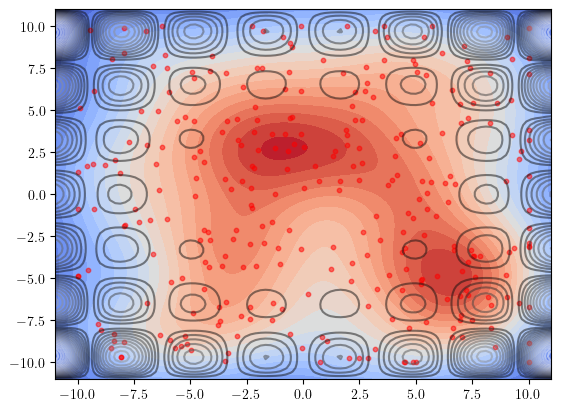

In [17]:
f = f_()

bounds = f.visual_bounds
sigma = 1 / n_particles**2
verbose = False

opt = gcn_opt(bounds=bounds, n_particles=n_particles, iter=iter, verbose=verbose, dt=dt)
res = opt.minimize(f)
print(f"Results for {opt}: {res[1]}")
f.visualize_density(iter, n_particles, snapshot)
plt.savefig("exploration_gcn_cbo.svg", bbox_inches="tight")

In [18]:
gcn_cbo_max, gcn_cbo_mean, gcn_cbo_var = f.visualize_distance(iter, n_particles)

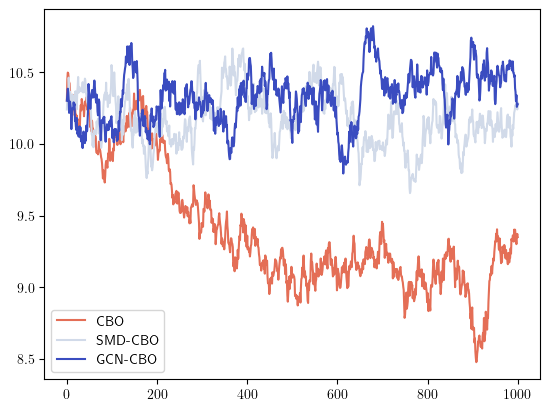

In [19]:
fig, ax = plt.subplots()
ax.plot(cbo_mean, label=r"CBO", c="#e46e56")
ax.plot(smd_cbo_mean, label=r"SMD-CBO", c="#d1dae9")
ax.plot(gcn_cbo_mean, label=r"GCN-CBO", c="#3a4cc0")
ax.legend()
plt.savefig("exploration_mean.svg", bbox_inches="tight")

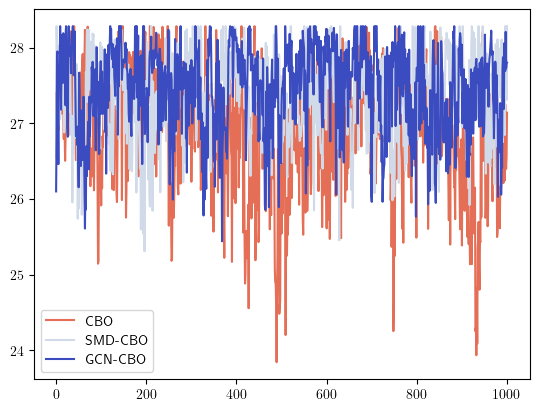

In [20]:
fig, ax = plt.subplots()
ax.plot(cbo_max, label=r"CBO", c="#e46e56")
ax.plot(smd_cbo_max, label=r"SMD-CBO", c="#d1dae9")
ax.plot(gcn_cbo_max, label=r"GCN-CBO", c="#3a4cc0")
ax.legend()
plt.savefig("exploration_max.svg", bbox_inches="tight")

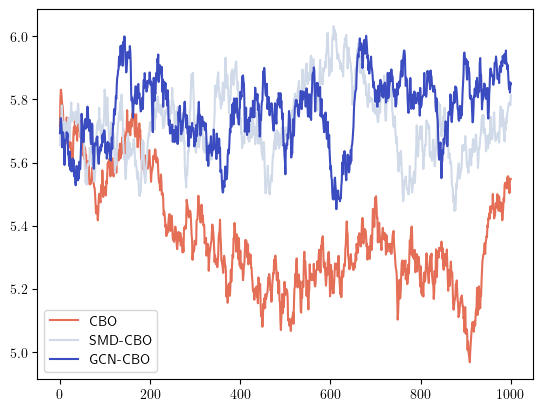

In [21]:
fig, ax = plt.subplots()
ax.plot(cbo_var, label=r"CBO", c="#e46e56")
ax.plot(smd_cbo_var, label=r"SMD-CBO", c="#d1dae9")
ax.plot(gcn_cbo_var, label=r"GCN-CBO", c="#3a4cc0")
ax.legend()
plt.savefig("exploration_var.svg", bbox_inches="tight")

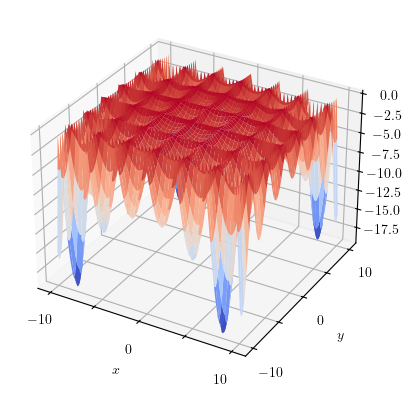

In [14]:
ben = f.func
bounds = ben.visual_bounds
x = np.linspace(bounds[0][0], bounds[0][1], 500)
y = np.linspace(bounds[1][0], bounds[1][1], 500)
X, Y = np.meshgrid(x, y)
Z = np.array(
    [ben(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))]
).reshape(X.shape)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, Y, Z, cmap="coolwarm")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_box_aspect(None)
xticks = ax.xaxis.get_major_ticks()
yticks = ax.yaxis.get_major_ticks()
for i in range(0, len(xticks), 2):
    xticks[i].label1.set_visible(False)
for i in range(0, len(yticks), 2):
    yticks[i].label1.set_visible(False)
plt.savefig("exploration_func.svg", bbox_inches="tight")